# Determine sky position of source using a Bayesian method

- Amplitude measurement is good.
- Phase measurement is jittery --> add some jitter to phase in compute response.

What amount of phase accuracy do we need for a decent skymap?

## Read in fits data

In [1]:
import numpy as np

In [2]:
import numpy as np

def single_band_network_response_analyzer(fits, f_gw1):
    
    # 1. Reconstruct Complex Signals for Band 1
    fit_S = []
    for fit in fits:
        # Create complex signal S = A * e^(i*phi)
        fit_S.append(fit['amplitude'] * np.exp(1j * fit['phase']))
    
    fit_S = np.array(fit_S)

    # 2. Extract Errors
    phases_err = []
    rel_amp_err = []

    for fit in fits:
        phases_err.append(fit['phase_err'])
        # Added a check to avoid division by zero
        amp = fit['amplitude'] if fit['amplitude'] != 0 else 1.0e-20
        rel_amp_err.append(np.abs(fit['amplitude_err'] / amp))

    phases_err = np.array(phases_err)
    rel_amp_err = np.array(rel_amp_err)

    # 3. Calculate Normalized Antenna Response
    # Normalizes all signals relative to the first detector (fit_S[0])
    # The term (np.exp(-1j*2*np.pi*f_gw1)) applies a constant phase shift 
    antenna_response = fit_S / fit_S[0] / np.exp(-1j * 2 * np.pi * f_gw1)
    
    # 4. Calculate Final Outputs
    antenna_response_amp = np.abs(antenna_response)
    
    # Propagate Error: New Amp * Original Relative Error
    antenna_response_amp_err = antenna_response_amp * rel_amp_err
    
    antenna_response_phase = np.angle(antenna_response)
    antenna_response_phase_err = phases_err
    
    return (antenna_response_amp, antenna_response_amp_err, antenna_response_phase, antenna_response_phase_err)

In [3]:
import pickle
data = pickle.load(open('resp1000_1000.pkl', 'rb'))

S = data[0]
amp_error = data[2]
phase_error = data[3]
data


([(2.941495448888877e-21+1.814386444415839e-20j),
  (-1.6041341813410008e-21+3.836401383523209e-21j),
  (-5.6987767680165476e-21-8.932426645201457e-22j),
  (-3.205887850350653e-21+2.0635212123469806e-20j),
  (-6.129314166038597e-21+1.0547755340373838e-21j),
  (5.985252969352953e-22-1.049094158532549e-20j)],
 97303.33457297274,
 [0.0063644644121829625,
  0.0168462785037386,
  0.01574130092693442,
  0.004910983292906998,
  0.01320531623479402,
  0.008345788477988522],
 [0.004089379035763988,
  0.01932071358367704,
  0.010839462773923952,
  0.0032392787826053186,
  0.009991147189581748,
  0.007298917751264422],
 [(2.8146221422345588e-21+1.84777829224187e-20j),
  (-1.5607475546395712e-21+3.852745620590698e-21j),
  (-5.746567700954756e-21-8.614903563358098e-22j),
  (-3.26754650642577e-21+2.08248657549209e-20j),
  (-6.173731984575546e-21+1.021818613125164e-21j),
  (4.517267206135127e-22-1.060086770739419e-20j)])

In [4]:
##Measurement Cycles
f_gw1 = 1/100 ##Keep this in the 10s of mHz 

# BAYESIAN SKY LOC INFERENCE

In [5]:
import bilby
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import norm
from bilby.core.utils import random

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

f0 = 429e12
h_const = lal.H_SI
G = lal.G_SI
c = lal.C_SI
M0 = lal.MSUN_SI

In [6]:

def normalize_with_errors(z, rel_amp_err, phase_err):
    """
    Parameters
    ----------
    z : array_like (complex)
        Complex numbers z_k
    rel_amp_err : array_like (float)
        Relative amplitude errors (sigma_Ak / Ak)
    phase_err : array_like (float)
        Absolute phase errors (radians)

    Returns
    -------
    r : complex ndarray
        Normalized complex list z_k / z_0
    sigma_re : ndarray
        Error on real part of normalized response
    sigma_im : ndarray
        Error on imaginary part of normalized response
    sigma_A0 : float
        Absolute error on overall magnitude |z_0|
    """

    z = np.asarray(z)
    rel_amp_err = np.asarray(rel_amp_err)
    phase_err = np.asarray(phase_err)

    A = np.abs(z)
    phi = np.angle(z)

    # Normalization reference
    A0 = A[0]
    phi0 = phi[0]

    # Overall magnitude error
    sigma_A0 = rel_amp_err[0] * A0

    # Relative amplitudes and phase differences
    alpha = A / A0
    delta_phi = phi - phi0

    # Relative amplitude errors (ratio propagation)
    sigma_alpha = alpha * np.sqrt(rel_amp_err**2 + rel_amp_err[0]**2)

    # Phase difference errors
    sigma_delta_phi = np.sqrt(phase_err**2 + phase_err[0]**2)

    # Normalized complex response
    r = alpha * np.exp(1j * delta_phi)

    # Real and imaginary parts
    cos = np.cos(delta_phi)
    sin = np.sin(delta_phi)

    # Error propagation
    sigma_re = np.sqrt(
        (cos**2) * sigma_alpha**2 +
        (alpha**2) * (sin**2) * sigma_delta_phi**2
    )

    sigma_im = np.sqrt(
        (sin**2) * sigma_alpha**2 +
        (alpha**2) * (cos**2) * sigma_delta_phi**2
    )

    return r, A0, sigma_re, sigma_im, sigma_A0
data_S, data_A, sigma_S_re, sigma_S_im, sigma_A = normalize_with_errors(S,amp_error,phase_error)


# Detector Network

In [7]:
N_detectors = 3

theta_1 = 0
theta_2 = np.pi/3
theta_3 = np.pi/6



r = 1.46e11 #metres



# Measurement frequency and Chirp Mass

In [8]:
f_gw=0.01
Mc = 1000*M0

# GW MODEL

In [9]:

def compute_fd_complex_response(f_gw,A, ra, dec, iota, psi):
    # GW propagation vector
    positions = np.array([[r*np.cos(theta_1),r*np.sin(theta_1),0],[r*np.cos(theta_2),r*np.sin(theta_3),0],[r*np.cos(theta_3),r*np.sin(theta_3),0],[r*np.cos(theta_1),r*np.sin(theta_1),0],[r*np.cos(theta_2),r*np.sin(theta_3),0],[r*np.cos(theta_3),r*np.sin(theta_3),0]])
    arms = np.array([[np.sin(theta_1),np.cos(theta_1),0],[np.sin(theta_2),np.cos(theta_2),0],[np.sin(theta_3),np.cos(theta_3),0],[-np.sin(theta_1),-np.cos(theta_1),0],[-np.sin(theta_2),-np.cos(theta_2),0],[-np.sin(theta_3),-np.cos(theta_3),0]])
    arm_lengths = [1e10,1e10,1e10,1e10,1e10,1e10]
    arm_lengths = np.array(arm_lengths)

    theta, phi = bilby.core.utils.conversion.ra_dec_to_theta_phi(ra, dec, 0)
    k = -np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])
    # 1. Amplitudes

    A_cross  = A*np.cos(iota)
    A_plus = A*(1+np.cos(iota)**2)/2
    
    def make_perp_basis(k):
        k = k / np.linalg.norm(k)
        if np.abs(k[2]) < 0.99:
            tmp = np.array([0,0,1])
        else:
            tmp = np.array([1,0,0])
        ex = np.cross(tmp, k)
        ex /= np.linalg.norm(ex)
        ey = np.cross(k, ex)
        return ex, ey

    ex, ey = make_perp_basis(k)

    # Polarization tensors
    e_plus = np.outer(ex, ex) - np.outer(ey, ey)
    e_cross = np.outer(ex, ey) + np.outer(ey, ex)

    # Rotate by polarization angle psi
    e_plus_rot  = e_plus * np.cos(2 * psi) + e_cross * np.sin(2 * psi)
    e_cross_rot = -e_plus * np.sin(2 * psi) + e_cross * np.cos(2 * psi)

    # --- CLOCK ANTENNA GEOMETRY ---
    # n̂ = photon propagation direction
    nk = np.einsum("di,i->d", arms, k)
    denom = 1.0 - nk

    # Geometry-only detector tensor
    D = 0.5 * np.einsum("di,dj->dij", arms, arms) / denom[:, None, None]

    # Antenna factors
    F_plus  = np.einsum("dij,ij->d", D, e_plus_rot)
    F_cross = np.einsum("dij,ij->d", D, e_cross_rot)

    # Keep original phase convention
    tau = np.dot(positions, k) / c
   
    phase_delay = 2 * np.pi * f_gw * arm_lengths * denom / c
    transfer = 1.0 - np.exp(-1j * phase_delay)
   
    # Pure antenna-pattern response (no transfer function)
    S = (F_plus * A_plus + 1j*F_cross * A_cross) * np.exp(-1j * 2 * np.pi * f_gw * tau) * transfer
    
    S_model = S/S[0]
    
    A_model = np.abs(S[0])
    
    return S_model, A_model


# LIKELIHOOD CLASS

In [10]:
arm_lengths = [1e10, 1e10, 1e10, 1e10, 1e10, 1e10]
class GWNetworkLikelihood(bilby.likelihood.Likelihood):
    def __init__(self, data_S,data_A, error_S_re,error_S_im,error_A, model):
        # We only accept Complex Strain (S) data, NO time delay (tau) data
        self.data_S = data_S  
        self.data_A = data_A# Complex array [Amp * exp(i*Phase)]
        self.error_S_re = error_S_re   # Error array
        self.error_S_im = error_S_im   # Error array
        self.error_A = error_A   # Error array
        self.model = model 

        super().__init__(parameters={'ra': None, 'dec': None, 
                                     'A': None, 'iota': None,
                                     'psi': None})

    def log_likelihood(self):
        S_model, A_model = self.model(f_gw, **self.parameters)

        try:
            S_model, A_model = self.model(f_gw, **self.parameters)
        except Exception as e:
            print('model not working')
            return -np.inf
        
        
        delta_S = self.data_S - S_model
        

        # Split into Real and Imaginary parts
        delta_S_re = np.real(delta_S)
        delta_S_im = np.imag(delta_S)
        delta_A = self.data_A-A_model
        
        sigma_S_re = self.error_S_re**2
        sigma_S_im = self.error_S_im**2
        sigma_A = self.error_A**2
        
        # Calculate chi-squared for Real and Imaginary parts
        ln_L_S_re = -0.5 * np.sum((delta_S_re**2 / sigma_S_re) + np.log(2 * np.pi * sigma_S_re))
        ln_L_S_im = -0.5 * np.sum((delta_S_im**2 / sigma_S_im) + np.log(2 * np.pi * sigma_S_im))
        ln_L_A = -0.5 * np.sum((delta_A**2 / sigma_A) + np.log(2 * np.pi * sigma_A))
        
        # Total Likelihood is just the Strain part
        return ln_L_S_re + ln_L_S_im + ln_L_A


# SETUP

In [11]:
label = "gw_localization"
outdir = "outdir_ra_dec_A_iota_psi_1012"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)
random.seed(123)
rng = np.random.default_rng(123) # Use a modern random number generator

# INJECTION

In [12]:
def get_dL(Mc, A, f_gw):
    "get dL in Mpc; A from https://arxiv.org/pdf/2507.10597"
    return f_gw**(-7/6) * (1./A) * (5./(24 * np.pi ** (4/3))) * ((G * Mc*2e30) **(5./6.))/c**(3./2.) * 3.2407792896664e-26

In [13]:
get_dL(1000, 1e-20, 0.01)

113.72093774039392

In [14]:
injection_parameters = dict(
    ra=0.2 +np.pi,                 # Right Ascension (rad)
    dec=np.pi/2 - 0.8 ,                # Declination (rad)
    psi=np.pi/3,               # Polarization angle (rad)
    A  = 1e-20,
    iota = np.pi/3
)
#time_delay_ref=0.0  # Reference time delay

# GENERATE DATA

In [15]:
# Generate NEW clean data using the NO-DELAY model
S_true, A_true = compute_fd_complex_response(f_gw, **injection_parameters)
N_detectors = 6
# Add noise
sigma_S = np.ones(N_detectors) * 0.01
sigma_A = A_true*0.01
data_S = S_true + rng.normal(0, sigma_S, N_detectors) + 1j * rng.normal(0, sigma_S, N_detectors)
data_A = A_true + rng.normal(0,sigma_A)

sigma_S_re = sigma_S
sigma_S_im = sigma_S
print("Data Generated.")


# Instantiate Likelihood

In [16]:
# Re-initialize likelihood with new data
safe_factor = 1
likelihood = GWNetworkLikelihood(
    data_S=data_S,
    data_A = data_A,
    error_S_re=sigma_S_re * safe_factor,
    error_S_im=sigma_S_im * safe_factor,
    error_A = sigma_A * safe_factor,
    model=compute_fd_complex_response
)

    

# Test at Injection
likelihood.parameters.update(injection_parameters)
print(f"Log Likelihood at Injection: {likelihood.log_likelihood()}")

Log Likelihood at Injection: -37331.9687635968


# PRIORS

In [17]:
# Define Priors (We want to sample the full sky)
priors = bilby.core.prior.PriorDict()
priors["dec"] = bilby.core.prior.Cosine(name='dec')
priors["ra"] = bilby.core.prior.Uniform(name='ra', minimum=0, maximum=2 * np.pi, boundary='periodic')
priors["psi"] = bilby.core.prior.Uniform(0, np.pi, "psi", latex_label=r"\psi")
priors["iota"] = bilby.core.prior.Sine(name=r"\iota")
priors["A"] = bilby.core.prior.LogUniform(1e-21, 1e-19, "A_plus", latex_label=r"A_+")
#priors["A_cross"] = bilby.core.prior.LogUniform(1e-22, 1e-20, "A_cross", latex_label=r"A_\times")
#priors["f_gw"] = injection_parameters["f_gw"] # Fix frequency for simplicity
#priors["time_delay_ref"] = 0 # Fix reference time delay

# ERROR ANALYSIS

In [18]:
# 1. Test the likelihood at the TRUE injection parameters
likelihood.parameters.update(injection_parameters)
log_l_true = likelihood.log_likelihood()

print(f"Log Likelihood at Injection: {log_l_true}")

# 2. Test the likelihood at a RANDOM point
likelihood.parameters.update(priors.sample())
log_l_random = likelihood.log_likelihood()

print(f"Log Likelihood at Random Point: {log_l_random}")

Log Likelihood at Injection: -37331.9687635968
Log Likelihood at Random Point: -47217.65238057167


# RUN SAMPLER

In [19]:
from tqdm import tqdm
print("Starting BILBY sampler for GW localization...")
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",
    nlive=250,  # Increased nlive for better sky sampling
    nact=5,
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    check_point_plot=True,
    seed=123,
    print_method='interval-60',
    result_class=bilby.gw.result.CBCResult #bilby.core.result.Result
)

# Finally plot a corner plot
result.plot_corner()

print(f"\nSampling complete. Results saved to {outdir}/{label}_result.json")

13:04 bilby INFO    : Running for label 'gw_localization', output will be saved to 'outdir_ra_dec_A_iota_psi_1012'


Starting BILBY sampler for GW localization...


13:04 bilby INFO    : Analysis priors:
13:04 bilby INFO    : dec=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None)
13:04 bilby INFO    : ra=Uniform(minimum=0, maximum=6.283185307179586, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary='periodic')
13:04 bilby INFO    : psi=Uniform(minimum=0, maximum=3.141592653589793, name='psi', latex_label='\\psi', unit=None, boundary=None)
13:04 bilby INFO    : iota=Sine(minimum=0, maximum=3.141592653589793, name='\\iota', latex_label='\\iota', unit=None, boundary=None)
13:04 bilby INFO    : A=LogUniform(minimum=1e-21, maximum=1e-19, name='A_plus', latex_label='A_+', unit=None, boundary=None)
13:04 bilby INFO    : Analysis likelihood class: <class '__main__.GWNetworkLikelihood'>
13:04 bilby INFO    : Analysis likelihood noise evidence: nan
13:04 bilby INFO    : Single likelihood evaluation took 3.544e-04 s
13:04 bilby WARNING : Kwargs contain both 'rstate' 

1305it [0:02:24 bound:275 nc:803 ncall:3.6e+05 eff:0.4% logz=-18239.18+/-0.21 dlogz:1.37e+04>0.1]
1458it [0:03:45 bound:398 nc:6932 ncall:5.1e+05 eff:0.3% logz=-15297.90+/-0.22 dlogz:1.09e+04>0.1]
1639it [0:04:48 bound:540 nc:1823 ncall:7.2e+05 eff:0.2% logz=-12368.74+/-0.23 dlogz:7.97e+03>0.1]
1781it [0:05:51 bound:681 nc:563 ncall:9.0e+05 eff:0.2% logz=-10967.09+/-0.23 dlogz:7.34e+03>0.1]
1914it [0:06:52 bound:810 nc:1368 ncall:1.0e+06 eff:0.2% logz=-10051.95+/-0.23 dlogz:6.41e+03>0.1]
2003it [0:08:06 bound:899 nc:5949 ncall:1.2e+06 eff:0.2% logz=-9428.51+/-0.24 dlogz:5.79e+03>0.1]


13:12 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1012/gw_localization_resume.pickle
/opt/anaconda3/lib/python3.12/site-packages/dynesty/plotting.py:786: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0., max(y0) * 1.05])
/opt/anaconda3/lib/python3.12/site-packages/dynesty/plotting.py:786: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0., max(y0) * 1.05])
/opt/anaconda3/lib/python3.12/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


...

5504it [0:40:30 bound:4307 nc:1710 ncall:6.7e+06 eff:0.1% logz=-3020.46+/-0.30 dlogz:21>0.1]
5586it [0:41:35 bound:4389 nc:2507 ncall:6.8e+06 eff:0.1% logz=-3018.35+/-0.30 dlogz:18.6>0.1]
5698it [0:42:36 bound:4502 nc:1200 ncall:7.0e+06 eff:0.1% logz=-3015.47+/-0.31 dlogz:15.9>0.1]
5815it [0:43:42 bound:4619 nc:2112 ncall:7.2e+06 eff:0.1% logz=-3013.12+/-0.31 dlogz:14.7>0.1]
5927it [0:44:50 bound:4731 nc:3864 ncall:7.4e+06 eff:0.1% logz=-3011.08+/-0.31 dlogz:12.7>0.1]
6054it [0:45:50 bound:4858 nc:1143 ncall:7.6e+06 eff:0.1% logz=-3009.05+/-0.31 dlogz:10.2>0.1]
6182it [0:46:53 bound:4986 nc:1021 ncall:7.8e+06 eff:0.1% logz=-3007.59+/-0.31 dlogz:8.51>0.1]
6308it [0:47:55 bound:5113 nc:1100 ncall:7.9e+06 eff:0.1% logz=-3006.52+/-0.31 dlogz:6.93>0.1]
6426it [0:48:58 bound:5231 nc:1250 ncall:8.1e+06 eff:0.1% logz=-3005.68+/-0.31 dlogz:6>0.1]


13:53 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1012/gw_localization_resume.pickle
/opt/anaconda3/lib/python3.12/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


6564it [0:50:01 bound:5370 nc:1038 ncall:8.3e+06 eff:0.1% logz=-3004.88+/-0.32 dlogz:5.76>0.1]
6690it [0:51:03 bound:5497 nc:1349 ncall:8.4e+06 eff:0.1% logz=-3004.27+/-0.32 dlogz:4.65>0.1]
6841it [0:52:05 bound:5649 nc:1385 ncall:8.6e+06 eff:0.1% logz=-3003.70+/-0.32 dlogz:3.59>0.1]
7004it [0:53:06 bound:5813 nc:789 ncall:8.8e+06 eff:0.1% logz=-3003.26+/-0.32 dlogz:2.83>0.1]
7148it [0:54:08 bound:5957 nc:1198 ncall:9.0e+06 eff:0.1% logz=-3002.96+/-0.32 dlogz:2.04>0.1]
7299it [0:55:09 bound:6109 nc:888 ncall:9.1e+06 eff:0.1% logz=-3002.73+/-0.32 dlogz:1.36>0.1]
7441it [0:56:12 bound:6251 nc:1143 ncall:9.3e+06 eff:0.1% logz=-3002.57+/-0.32 dlogz:0.874>0.1]
7622it [0:57:16 bound:6432 nc:1899 ncall:9.5e+06 eff:0.1% logz=-3002.43+/-0.33 dlogz:0.481>0.1]
7804it [0:58:18 bound:6614 nc:628 ncall:9.7e+06 eff:0.1% logz=-3002.34+/-0.33 dlogz:0.312>0.1]
7957it [0:59:19 bound:6762 nc:743 ncall:9.8e+06 eff:0.1% logz=-3002.29+/-0.33 dlogz:0.174>0.1]


14:03 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1012/gw_localization_resume.pickle
/opt/anaconda3/lib/python3.12/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])
14:03 bilby INFO    : Written checkpoint file outdir_ra_dec_A_iota_psi_1012/gw_localization_resume.pickle
/opt/anaconda3/lib/python3.12/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])
14:03 bilby INFO    : Rejection sampling nested samples to obtain 1168 posterior samples
14:03 bilby INFO    : Sampling time: 1:00:13.117813
14:03 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
14:03 bilby WARNING


Sampling complete. Results saved to outdir_ra_dec_A_iota_psi_1012/gw_localization_result.json


In [20]:
import matplotlib.pyplot as plt

import json

results_name = "outdir_ra_dec_A_iota_psi_1012/gw_localization_result.json"

with open(results_name, 'r') as file:
    data = json.load(file)

print(data.keys())

dict_keys(['label', 'outdir', 'sampler', 'log_evidence', 'log_evidence_err', 'log_noise_evidence', 'log_bayes_factor', 'priors', 'posterior', 'injection_parameters', 'meta_data', 'search_parameter_keys', 'fixed_parameter_keys', 'constraint_parameter_keys', 'sampling_time', 'sampler_kwargs', 'use_ratio', 'information_gain', 'log_likelihood_evaluations', 'log_prior_evaluations', 'num_likelihood_evaluations', 'samples', 'nested_samples', 'parameter_labels', 'parameter_labels_with_unit', 'version'])


In [21]:
data['search_parameter_keys']

['dec', 'ra', 'psi', 'iota', 'A']

In [22]:
from operator import itemgetter

dec_samples = list(map(itemgetter(0), data['samples']['content']))
ra_samples = list(map(itemgetter(1), data['samples']['content']))

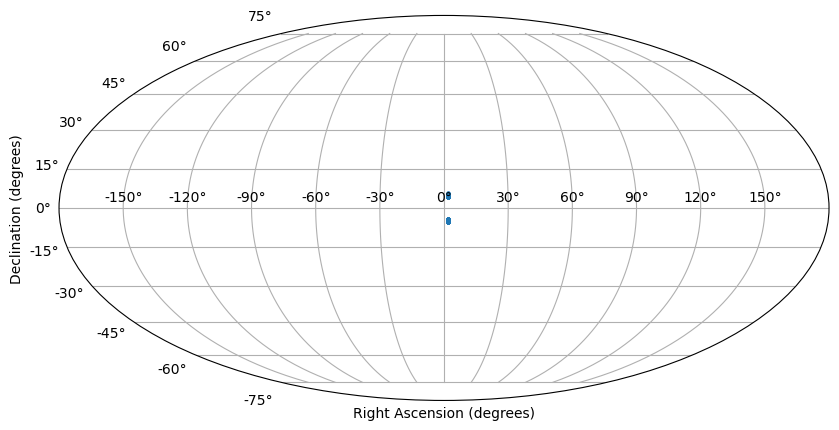

<Figure size 640x480 with 0 Axes>

In [23]:
def plot_mwd_radec(RA, Dec, name='skymap_1003.png', org=0):
    """
    Creates a Mollweide projection plot from RA and Dec samples.
    RA values should be in [0, 360), Dec in [-90, 90], in degrees.
    org sets the central longitude (e.g., 0 or 180 for the galactic center).
    """

    x_rad = RA 
    Dec_rad = Dec

    fig = plt.figure(figsize=(10, 5))

    ax = fig.add_subplot(111, projection='mollweide')
    
    ax.scatter(x_rad, Dec_rad, s=4, alpha=1)

    ax.set_xlabel("Right Ascension (degrees)")
    ax.set_ylabel("Declination (degrees)")
    ax.grid(True)
    plt.show()
    plt.savefig(name)

plot_mwd_radec(ra_samples, dec_samples)


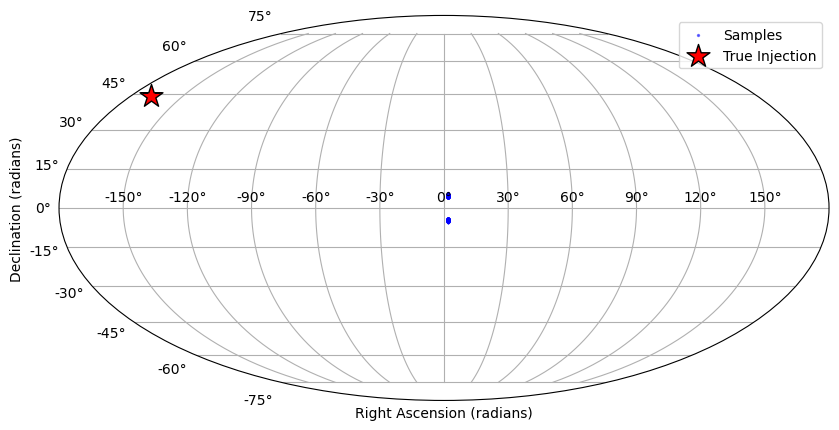

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mwd_radec_radians(ra_rad, dec_rad, true_ra=None, true_dec=None, name='skymap_injection.png'):
    """
    Creates a Mollweide projection plot.
    EXPECTS INPUTS IN RADIANS.
    """
    
    # 1. Wrap RA to fit within [-pi, pi] for the plot
    # The injection is (0.2 + pi), which is > pi, so we must shift it.
    ra_rad = np.remainder(ra_rad + np.pi, 2*np.pi) - np.pi
    
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection='mollweide')

    # 2. Plot the Posterior Samples (Blue)
    ax.scatter(ra_rad, dec_rad, s=2, alpha=0.5, label='Samples', color='blue')

    # 3. Plot the True Injection (Red Star)
    if true_ra is not None and true_dec is not None:
        # Wrap the True RA as well
        t_ra = np.remainder(true_ra + np.pi, 2*np.pi) - np.pi
        
        ax.scatter(t_ra, true_dec, s=300, marker='*', color='red', 
                   edgecolor='black', zorder=10, label='True Injection')

    ax.set_xlabel("Right Ascension (radians)")
    ax.set_ylabel("Declination (radians)")
    ax.grid(True)
    ax.legend(loc='upper right')
    
    plt.savefig(name)
    plt.show()

# --- HOW TO RUN IT ---

# 1. Define your injection (from your snippet)
injection_parameters = dict(
    ra=0.2 + np.pi,   # ~3.34 radians
    dec=np.pi/2 - 0.8,   # ~0.77 radians
    psi=np.pi/3,
    A=1e-20,
    iota=np.pi/3
)

# 2. Check if your SAMPLES are in degrees or radians
# Bilby usually outputs radians, but check your result keys. 
# If they are degrees, uncomment the conversion line below:
ra_samples = np.deg2rad(result.posterior['ra']) 
dec_samples = np.deg2rad(result.posterior['dec'])

# If samples are ALREADY radians (standard for Bilby):
ra_samples = result.posterior['ra']
dec_samples = result.posterior['dec']

# 3. Plot!
plot_mwd_radec_radians(
    ra_samples, 
    dec_samples, 
    true_ra=injection_parameters['ra'], 
    true_dec=injection_parameters['dec']
)